# Módulo Visualização de Dados - E-commerce
Análise visual dos dados preparados do e-commerce de moda.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual padrão
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Leitura do arquivo
df = pd.read_csv('ecommerce_preparados.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2199, 24)


,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,0,Pijama Cirurgico Scrub Roupa Privativa Hospit...,4.0,273.0,NaN,toronto uniformes profissionais,poliéster,Sem gênero,não definido,"Preço justo , bem feito acabamento ok. Única s...",...,0.629630,0.029969,NaN,0.100645,781,122,1,1000.0,0.002274,0.117326
1,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
2,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
3,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
4,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466


## 1. Histograma — Distribuição das Notas dos Produtos

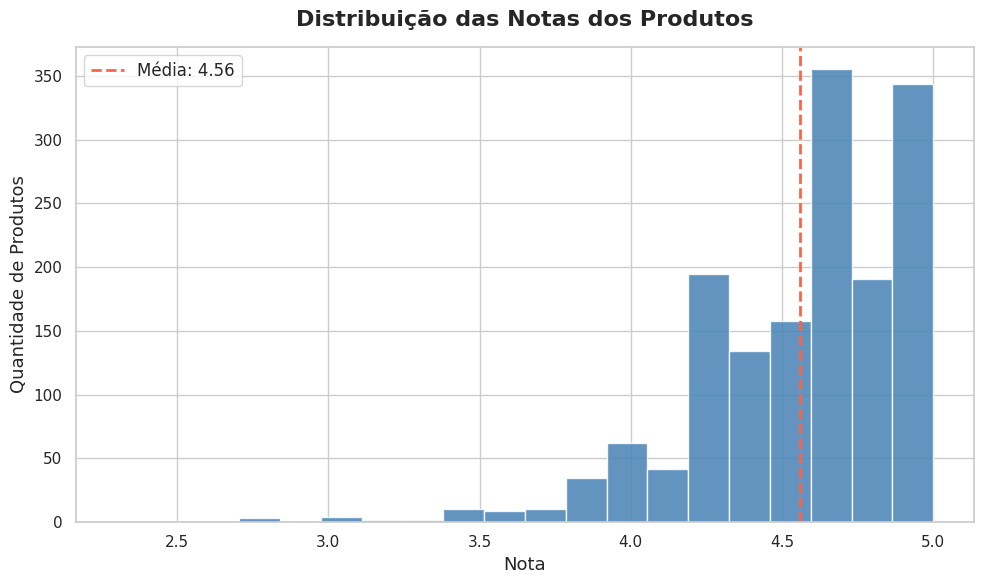

In [2]:
# Histograma da distribuição das notas dos produtos
# Objetivo: entender como as avaliações estão concentradas
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['Nota'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.85)

ax.set_title('Distribuição das Notas dos Produtos', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Nota', fontsize=13)
ax.set_ylabel('Quantidade de Produtos', fontsize=13)
ax.axvline(df['Nota'].mean(), color='tomato', linestyle='--', linewidth=2, label=f'Média: {df["Nota"].mean():.2f}')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

## 2. Gráfico de Dispersão — Preço vs Número de Avaliações

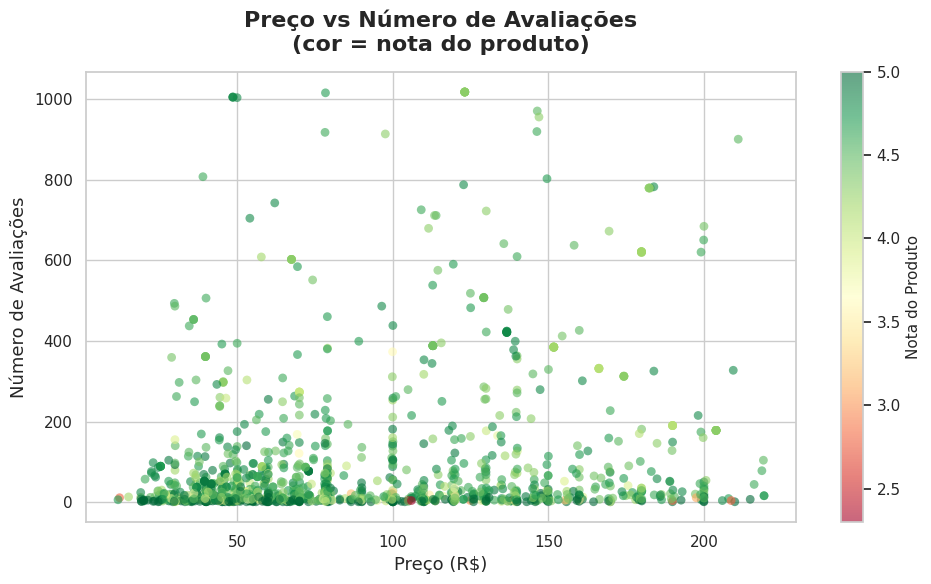

In [3]:
# Dispersão entre Preço e Número de Avaliações
# Objetivo: verificar se produtos mais baratos recebem mais avaliações
fig, ax = plt.subplots(figsize=(10, 6))

# Filtrar outliers extremos para melhor visualização
df_plot = df[(df['Preço'] < df['Preço'].quantile(0.95)) &
             (df['N_Avaliações'] < df['N_Avaliações'].quantile(0.95))]

scatter = ax.scatter(
    df_plot['Preço'], df_plot['N_Avaliações'],
    c=df_plot['Nota'], cmap='RdYlGn', alpha=0.6, s=40, edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Nota do Produto', fontsize=11)

ax.set_title('Preço vs Número de Avaliações\n(cor = nota do produto)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Preço (R$)', fontsize=13)
ax.set_ylabel('Número de Avaliações', fontsize=13)

plt.tight_layout()
plt.show()

## 3. Mapa de Calor — Correlação entre Variáveis Numéricas

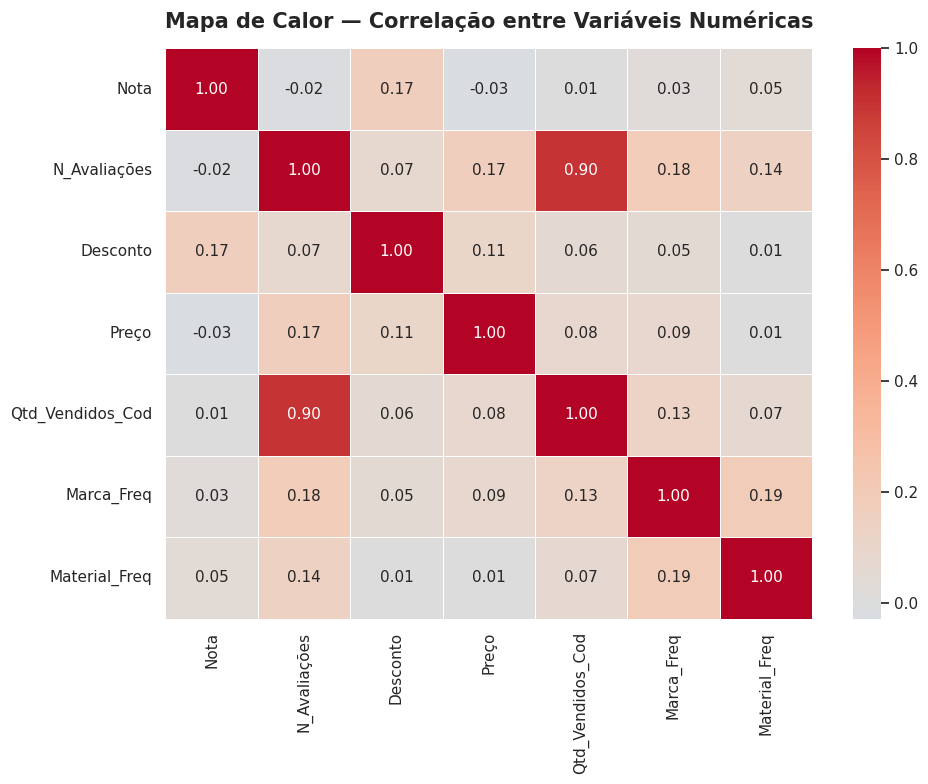

In [4]:
# Mapa de calor da correlação entre as variáveis numéricas
# Objetivo: identificar quais variáveis têm relação entre si
colunas_numericas = ['Nota', 'N_Avaliações', 'Desconto', 'Preço',
                     'Qtd_Vendidos_Cod', 'Marca_Freq', 'Material_Freq']

corr = df[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Mapa de Calor — Correlação entre Variáveis Numéricas', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Gráfico de Barras — Top 10 Marcas por Quantidade de Produtos

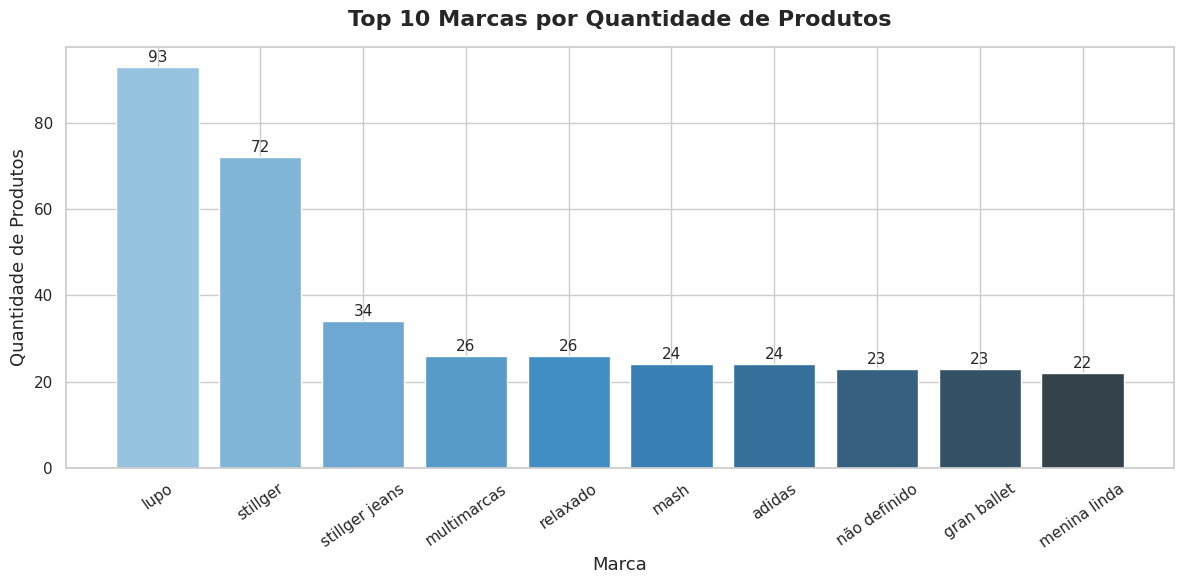

In [5]:
# Gráfico de barras com as 10 marcas mais frequentes
# Objetivo: identificar quais marcas dominam o catálogo
top_marcas = df['Marca'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_marcas.index, top_marcas.values,
              color=sns.color_palette('Blues_d', len(top_marcas)),
              edgecolor='white')

# Adicionar valores no topo das barras
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)

ax.set_title('Top 10 Marcas por Quantidade de Produtos', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=13)
ax.set_ylabel('Quantidade de Produtos', fontsize=13)
ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## 5. Gráfico de Pizza — Distribuição por Gênero

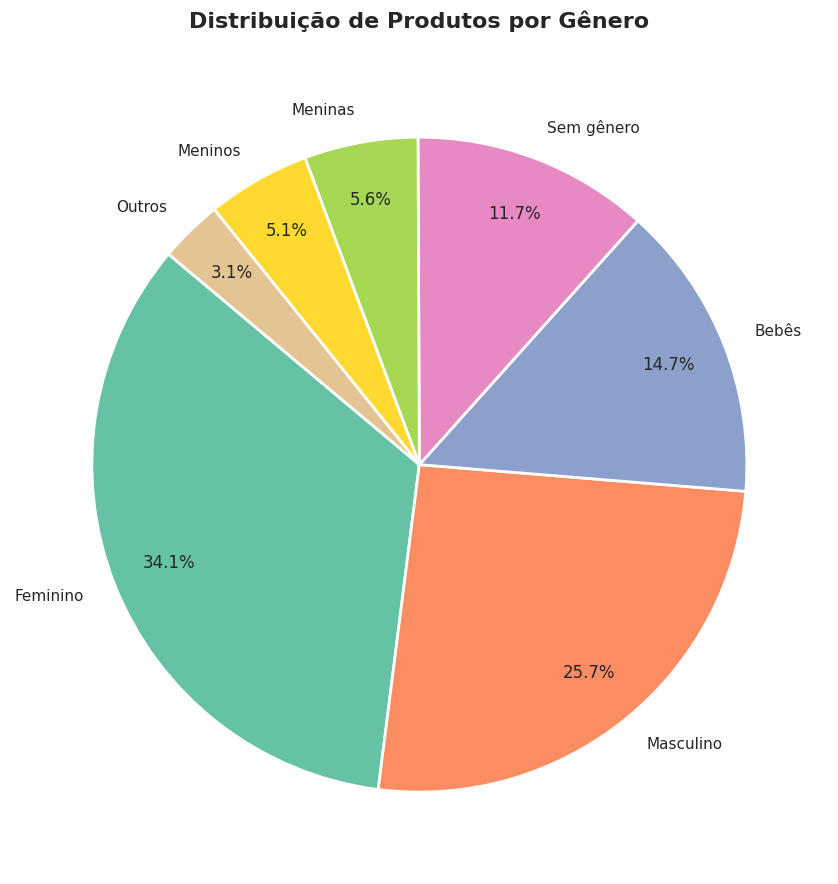

In [6]:
# Gráfico de pizza com distribuição por gênero
# Objetivo: visualizar a proporção de produtos por público-alvo

# Agrupar categorias menores em 'Outros'
genero_counts = df['Gênero'].value_counts()
principais = genero_counts[genero_counts >= 100]
outros = genero_counts[genero_counts < 100].sum()
if outros > 0:
    principais['Outros'] = outros

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    principais.values,
    labels=principais.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(principais)),
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in autotexts:
    text.set_fontsize(12)

ax.set_title('Distribuição de Produtos por Gênero', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 6. Gráfico de Densidade — Distribuição de Preços por Temporada

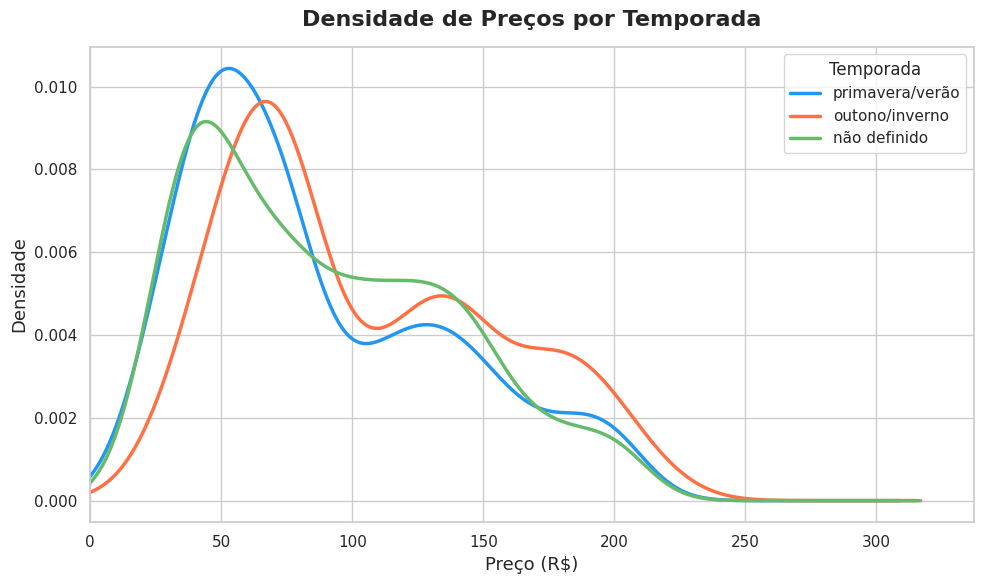

In [7]:
# Gráfico de densidade (KDE) de preços por temporada principal
# Objetivo: comparar a faixa de preços entre as temporadas
temporadas_principais = ['primavera/verão', 'outono/inverno', 'não definido']
df_temp = df[df['Temporada'].isin(temporadas_principais)]
df_temp = df_temp[df_temp['Preço'] < df_temp['Preço'].quantile(0.95)]

fig, ax = plt.subplots(figsize=(10, 6))
for temporada, cor in zip(temporadas_principais, ['#2196F3', '#FF7043', '#66BB6A']):
    subset = df_temp[df_temp['Temporada'] == temporada]['Preço'].dropna()
    subset.plot.kde(ax=ax, label=temporada, color=cor, linewidth=2.5)

ax.set_title('Densidade de Preços por Temporada', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Preço (R$)', fontsize=13)
ax.set_ylabel('Densidade', fontsize=13)
ax.legend(title='Temporada', fontsize=11)
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 7. Gráfico de Regressão — Desconto vs Quantidade Vendida

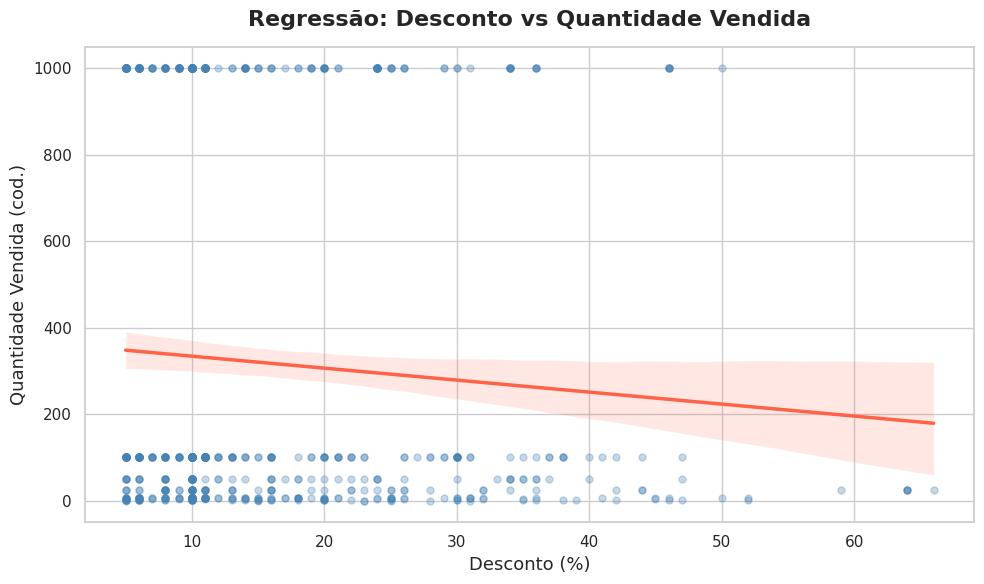

In [8]:
# Gráfico de regressão entre Desconto e Quantidade Vendida
# Objetivo: verificar se maiores descontos influenciam o volume de vendas
df_reg = df[['Desconto', 'Qtd_Vendidos_Cod']].dropna()
df_reg = df_reg[df_reg['Qtd_Vendidos_Cod'] < df_reg['Qtd_Vendidos_Cod'].quantile(0.95)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_reg,
    x='Desconto',
    y='Qtd_Vendidos_Cod',
    ax=ax,
    scatter_kws={'alpha': 0.3, 's': 25, 'color': 'steelblue'},
    line_kws={'color': 'tomato', 'linewidth': 2.5},
    ci=95
)

ax.set_title('Regressão: Desconto vs Quantidade Vendida', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Desconto (%)', fontsize=13)
ax.set_ylabel('Quantidade Vendida (cod.)', fontsize=13)

plt.tight_layout()
plt.show()